An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


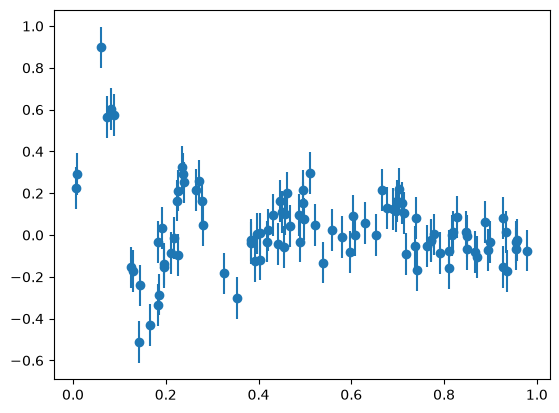

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax

num_data = 100;
noise_magnitude_on_each_point = 0.1;
k1, k2 = jr.split(jr.key(90))
x_obs = jr.uniform(k1, shape=(num_data,), minval=0.0, maxval=1.0)
y_obs_true = jnp.sin(30*x_obs) * jnp.exp(-5*x_obs)
y_obs_err = noise_magnitude_on_each_point * jnp.ones_like(y_obs_true)

y_obs = y_obs_true + y_obs_err * jr.normal(k2, shape=y_obs_true.shape)

plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
plt.show()

In [3]:
rng_key = jr.key(0);
num_fixed_points = 50;
total_length = 1;


fixed_points_linspace = jnp.linspace(0, total_length, num_fixed_points);
observed_indices = jnp.searchsorted(fixed_points_linspace, x_obs)

def matern_32(r, variance=1.0, scale=0.2, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter))

def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_fixed_points - 1);

shape = (num_fixed_points, num_fixed_points);
dist_matrix = jnp.fromfunction(dist_function, shape);
cov_matrix_matern_32 = matern_32(dist_matrix);

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
diag_cov_data_matrix = jnp.diag(diagonal_values)

def logdensity_fn(guess_values):
    # guess_values[observed_indices] is the same things as Rf; I just don't explicitly compute R here
    log_p_d_given_s = -0.5 * (guess_values[observed_indices] - y_obs).T @ jnp.linalg.inv(diag_cov_data_matrix) @ (guess_values[observed_indices] - y_obs)
    # add the log probabilities of P(d|s) and P(s)
    log_prior = -0.5*guess_values.T @ jnp.linalg.inv(cov_matrix_matern_32) @ guess_values
    return log_prior + log_p_d_given_s
   

In [4]:
inv_mass_matrix = cov_matrix_matern_32;
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity_fn, step_size, inv_mass_matrix, num_integration_steps)

initial_position = jnp.zeros(num_fixed_points)
initial_state = hmc.init(initial_position)
initial_state

HMCState(position=Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32), logdensity=Array(-205.6943, dtype=float32), logdensity_grad=Array([ 0.0000000e+00,  5.1636826e+01,  0.0000000e+00,  8.9736496e+01,
        5.6567810e+01,  1.1760799e+02,  0.0000000e+00, -8.3675575e+01,
       -2.4113077e+01, -7.9896355e+01, -5.4353054e+01, -1.0172568e+01,
        1.1538829e+02,  2.1450634e+01,  4.7336067e+01,  0.0000000e+00,
       -1.8365124e+01,  0.0000000e+00, -3.0064503e+01, -6.0457149e+00,
       -2.2786442e+01, -8.5372758e-01,  2.1696182e+01,  4.0024807e+01,
        9.5012779e+00,  4.1138153e+01,  3.4532433e+01, -1.3156128e+01,
        2.3848500e+00, -9.6314180e-01,  7.6059723e-01,  5.6120830e+00,
        4.9753301e-02,  2.1716938e+01,  2.5364773e+01,  7.5743607e+01,
       -9.1685848e+00, -1.4146020e+01, -

In [5]:
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states



rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop(sample_key, hmc_kernel, initial_state, 10_000)

mcmc_samples = states.position

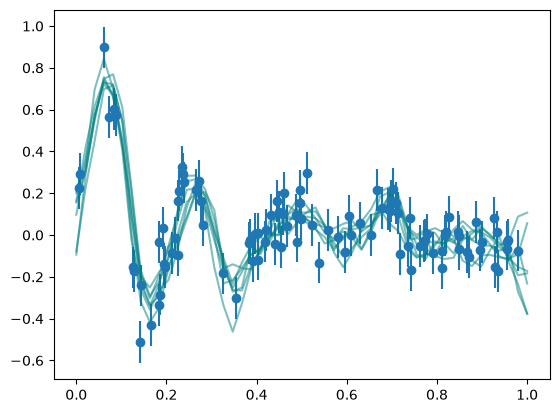

In [ ]:
#plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations')
for i in range(0, 7):
    plt.plot(fixed_points_linspace, mcmc_samples[2500 + i*1000, :], label = "Posterior Sample", alpha = 0.5, color = 'teal');
plt.plot(x, mean_sample_from_posterior, label = "Posterior Sample", alpha = 1);
plt.show();

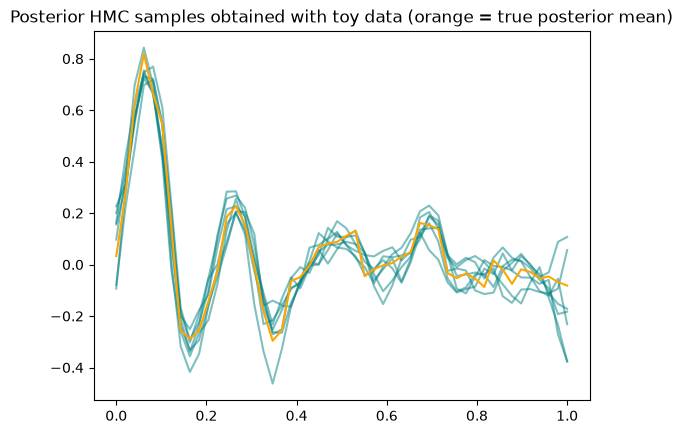

In [11]:
# Infer the mean function and draw posterior samples
num_entries = 50;
noise_magnitude_on_each_point = 0.1;
total_length = 1;

def matern_32(r, variance=1.0, scale=0.1, jitter=1e-6):
    result = variance * (1 + jnp.sqrt(3)*r/scale)*jnp.exp(-1*jnp.sqrt(3)*r/scale);
    return jnp.where(r > 0, result, result * (1.0 + jitter));


def dist_function(i, j):
    return jnp.abs(i - j)*total_length/(num_entries - 1);

shape = (num_entries, num_entries);
dist_matrix = jnp.fromfunction(dist_function, shape);
# I am choosing a Matern covariance with nu = 3/2 for the prior 
K = matern_32(dist_matrix);

N = jnp.eye(num_data)*noise_magnitude_on_each_point**2;

x = jnp.linspace(0, total_length, num_entries);
rng, key = jr.split(rng_key);
noise = jr.normal(key, shape = (len(x), 8000));

R = jnp.zeros((num_data, num_entries));
observed_indices = jnp.searchsorted(x, x_obs)
R = R.at[jnp.arange(num_data), observed_indices].set(1);


# below are the standard formulas 
#D = jnp.linalg.inv( jnp.linalg.inv(K) + R.T @ jnp.linalg.inv(N) @ R);
#M = D @ R.T @ jnp.linalg.inv(N) @ y_obs;
# below are the Woodbury formulas (AI told me about them in the process of debugging)
D = K - K @ R.T @ jnp.linalg.inv(R @ K @ R.T + N) @ R @ K;
M = K @ R.T @ jnp.linalg.inv(R @ K @ R.T + N) @ y_obs;


L_D = jnp.linalg.cholesky(D);
mean_sample_from_posterior = M;
noise_sample_from_posterior_array = M[:, None] + L_D @ noise
graphing_noise_sample_from_posterior_array = noise_sample_from_posterior_array[7990:]

# Plot these on top of the observations
#plt.errorbar(x_obs, y_obs, yerr=y_obs_err, fmt='o', label='Observations', alpha = 1)
#for i in range (0, 10):
    #plt.plot(x, noise_sample_from_posterior_array[:, i], label = "Noise Posterior Sample", alpha = 0.4, color = "red")
for i in range(0, 7):
    plt.plot(fixed_points_linspace, mcmc_samples[2500 + i*1000, :], label = "Posterior Sample", alpha = 0.5, color = 'teal');
plt.plot(x, mean_sample_from_posterior, label = "Posterior Sample", alpha = 1, color = "orange");
plt.title("Posterior HMC samples obtained with toy data (orange = true posterior mean)")
plt.show();

In [8]:
# do chi^2 analysis
filtered_samples = mcmc_samples[2000:]
gaussian_noise = jnp.linalg.inv(L_D) @ (filtered_samples.T - M[:, None])
normalized_chi_2_array = jnp.sum(gaussian_noise ** 2, axis=1)/8000
print(f"Normalized Chi^2 values for each of the 50 entires that should be Gaussian noise: \n {normalized_chi_2_array}")
overall_normalized_chi_2 = jnp.sum(normalized_chi_2_array)/50
print(f"Overall normalized chi^2: {overall_normalized_chi_2}")
gaussian_noise_control = jnp.linalg.inv(L_D) @ (noise_sample_from_posterior_array - M[:, None])
normalized_chi_2_array_control = jnp.sum(gaussian_noise_control ** 2, axis=1)/8000
print(f"Normalized Chi^2 values for control entries that REALLY should be Gaussian noise: \n {normalized_chi_2_array_control}")


Normalized Chi^2 values for each of the 50 entires that should be Gaussian noise: 
 [0.33529812 1.1142727  0.5960573  1.1835899  0.8322678  1.9481462
 0.3247629  1.7420448  0.71306586 0.77575105 0.9725458  0.85692984
 1.3898451  0.42778566 0.95612246 0.18781239 0.5951447  0.36255482
 0.83938366 1.0307987  0.80949515 0.88615984 0.62150145 0.7639123
 0.47525728 0.66163117 0.92923045 1.3856766  0.6683757  0.36381108
 0.7081411  0.39802033 0.46663272 0.5965696  0.705137   1.0197086
 0.5863767  0.7725865  0.77743495 0.6208473  1.2640767  1.4725682
 0.90101886 0.8173689  0.76853496 0.36964375 0.97957695 0.8608274
 0.7911393  0.19619285]
Overall normalized chi^2: 0.7964327335357666
Normalized Chi^2 values for control entries that REALLY should be Gaussian noise: 
 [0.9887359  0.9947782  0.9611264  0.99996996 1.0059731  0.99330485
 0.98924124 1.0363859  1.0069045  1.0076184  1.0050415  0.9955341
 1.0090151  1.0324554  0.9875932  1.0127356  0.98601174 0.99873155
 1.0091509  1.0053428  0.9899177